# Notebook 10 — Final Comparison & Paper Results
Loads saved outputs from all prior notebooks and produces a consolidated comparison table, visualisations, and print-ready findings.

**Sensitive attribute throughout: `fitness_level` only.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../results', exist_ok=True)

# ── Load all saved metrics ──────────────────────────────────────────
with open('../results/privacy_metrics_complete.json') as f:
    all_results = json.load(f)

with open('../results/hybrid1_metrics.json') as f:
    h1_metrics = json.load(f)

with open('../results/hybrid2_metrics.json') as f:
    h2_metrics = json.load(f)
with open('../results/hybrid3_metrics.json') as f:
    h3_metrics = json.load(f)

print('✅ All metrics loaded')
print(f"  Project: {all_results['project']}")
print(f"  Stages in complete results: {list(all_results['stages'].keys())}")

✅ All metrics loaded
  Project: Privacy-Preserving Fitness Data — fitness_level as sensitive attribute
  Stages in complete results: ['original', 'k_anonymity', 'l_diversity', 't_closeness']


In [2]:
# ── Load raw / processed datasets for utility calculation ───────────
df_original = pd.read_csv('../data/raw_fitness_data.csv')
df_k        = pd.read_csv('../data/k_anonymized.csv')
df_l        = pd.read_csv('../data/l_diverse.csv')
df_t        = pd.read_csv('../data/t_close_anonymized.csv')
df_h1       = pd.read_csv('../data/hybrid1_result.csv')
df_h2       = pd.read_csv('../data/hybrid2_result.csv')
df_h3       = pd.read_csv('../data/hybrid3_result.csv')

quasi_identifiers = ['age', 'region', 'activity']
fitness_classes   = ['fit', 'moderately_fit', 'unfit']

print('✅ All datasets loaded')

✅ All datasets loaded


In [3]:
# ── Helper functions ────────────────────────────────────────────────
def tvd(p, q):
    keys = q.index
    p_a = p.reindex(keys, fill_value=0)
    return 0.5 * sum(abs(p_a[i] - q[i]) for i in keys)


def inference_attack_accuracy(df_in, quasi_ids):
    """Attacker predicts most-frequent fitness_level per group."""
    correct = 0
    for _, gd in df_in.groupby(quasi_ids):
        predicted = gd['fitness_level'].mode().iloc[0]
        correct  += (gd['fitness_level'] == predicted).sum()
    return correct / len(df_in)


def mean_tvd_from_population(df_in, pop_dist, quasi_ids, fc):
    vals = []
    for _, gd in df_in.groupby(quasi_ids):
        gd_dist = gd['fitness_level'].value_counts(normalize=True).reindex(fc, fill_value=0)
        vals.append(tvd(gd_dist, pop_dist))
    return float(np.mean(vals))


def diversity_satisfaction(df_in, quasi_ids, l=3):
    """Fraction of groups satisfying L-diversity."""
    div = df_in.groupby(quasi_ids)['fitness_level'].nunique()
    return float((div >= l).mean())


def utility_score(df_in, df_ref, numeric_cols=None):
    """Utility proxy: 1 - mean normalised deviation of numeric attributes."""
    if numeric_cols is None:
        numeric_cols = ['steps', 'calories', 'heart_rate', 'sleep_hours']
    scores = []
    for col in numeric_cols:
        if col in df_in.columns and col in df_ref.columns:
            ref_std = df_ref[col].std()
            if ref_std > 0:
                deviation = abs(df_in[col].mean() - df_ref[col].mean()) / ref_std
                scores.append(max(0, 1 - deviation))
    return float(np.mean(scores)) if scores else 1.0


print('✅ Helper functions defined')

✅ Helper functions defined


In [4]:
# Population reference distribution
pop_fl_dist = df_original['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0)

# Compute all metrics
datasets = {
    'K-Anonymity':   df_k,
    'L-Diversity':   df_l,
    'T-Closeness':   df_t,
    'Hybrid Model 1': df_h1,
    'Hybrid Model 2': df_h2,
    'Hybrid Model 3': df_h3
}

rows = []
for method_name, df_m in datasets.items():
    attack_acc  = inference_attack_accuracy(df_m, quasi_identifiers)
    mean_tvd_v  = mean_tvd_from_population(df_m, pop_fl_dist, quasi_identifiers, fitness_classes)
    div_sat     = diversity_satisfaction(df_m, quasi_identifiers)
    util        = utility_score(df_m, df_original)
    violations  = sum(1 for _, gd in df_m.groupby(quasi_identifiers)
                      if tvd(gd['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0), pop_fl_dist) > 0.25)

    rows.append({
        'Method':                      method_name,
        'Inference Attack Accuracy':   round(attack_acc, 4),
        'Mean TVD (privacy metric)':   round(mean_tvd_v, 4),
        'L-Diversity Satisfaction (%)': round(div_sat * 100, 1),
        'T-Violations':                violations,
        'Utility Score':               round(util, 4),
        'Records':                     len(df_m)
    })

comparison_df = pd.DataFrame(rows)

print('='*100)
print('FINAL COMPARISON TABLE — Sensitive Attribute: fitness_level')
print('='*100)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('../results/final_comparison_table.csv', index=False)
print('\n✅ Saved: ../results/final_comparison_table.csv')

FINAL COMPARISON TABLE — Sensitive Attribute: fitness_level
        Method  Inference Attack Accuracy  Mean TVD (privacy metric)  L-Diversity Satisfaction (%)  T-Violations  Utility Score  Records
   K-Anonymity                     0.6897                     0.2812                          52.4            60            1.0     7000
   L-Diversity                     0.6861                     0.2829                          94.4            57            1.0     7000
   T-Closeness                     0.6793                     0.2617                          96.5            49            1.0     7000
Hybrid Model 1                     0.6563                     0.2375                          96.5            39            1.0     7000
Hybrid Model 2                     0.6434                     0.1989                          96.5            18            1.0     7000
Hybrid Model 3                     0.5441                     0.1617                          96.5            31      

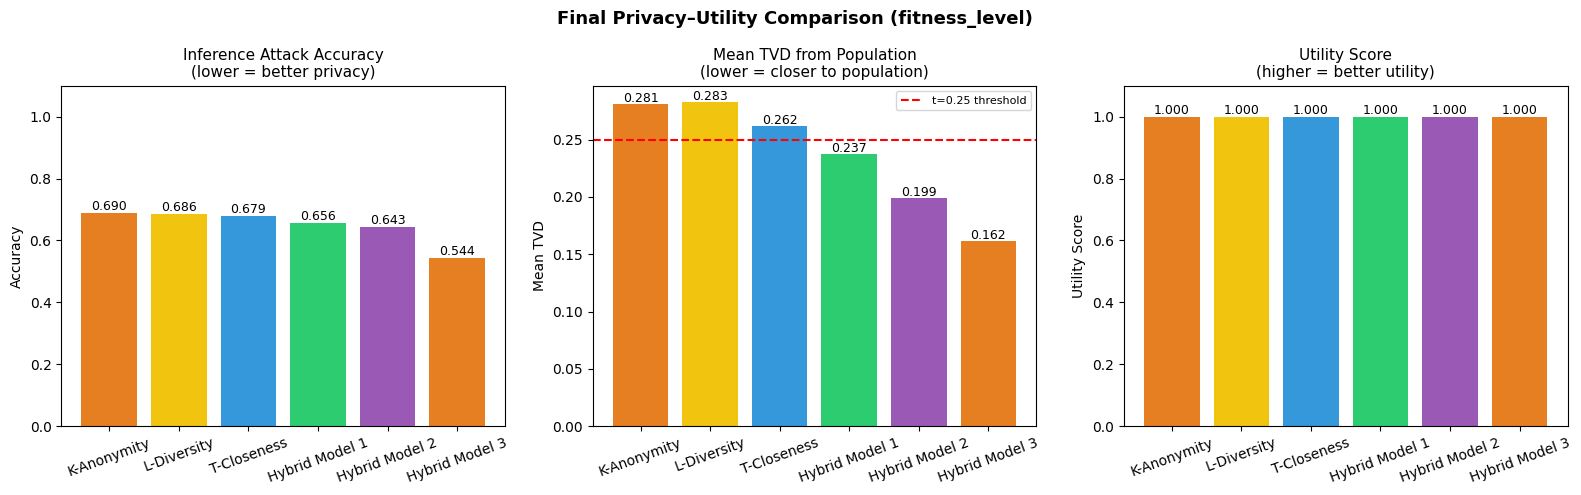

✅ Saved: ../results/10_final_comparison_bars.png


In [7]:
# ── Visualisation 1: Inference Attack Accuracy ──────────────────────
methods = comparison_df['Method'].tolist()
acc     = comparison_df['Inference Attack Accuracy'].tolist()
util    = comparison_df['Utility Score'].tolist()
tvds    = comparison_df['Mean TVD (privacy metric)'].tolist()

colours = ['#e67e22', '#f1c40f', '#3498db', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Attack accuracy
bars = axes[0].bar(methods, acc, color=colours)
axes[0].set_title('Inference Attack Accuracy\n(lower = better privacy)', fontsize=11)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=20)
for b, v in zip(bars, acc):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Mean TVD
bars2 = axes[1].bar(methods, tvds, color=colours)
axes[1].axhline(0.25, color='red', linestyle='--', label='t=0.25 threshold')
axes[1].set_title('Mean TVD from Population\n(lower = closer to population)', fontsize=11)
axes[1].set_ylabel('Mean TVD')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)
for b, v in zip(bars2, tvds):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

# Utility
bars3 = axes[2].bar(methods, util, color=colours)
axes[2].set_title('Utility Score\n(higher = better utility)', fontsize=11)
axes[2].set_ylabel('Utility Score')
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=20)
for b, v in zip(bars3, util):
    axes[2].text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Final Privacy–Utility Comparison (fitness_level)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/10_final_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/10_final_comparison_bars.png')

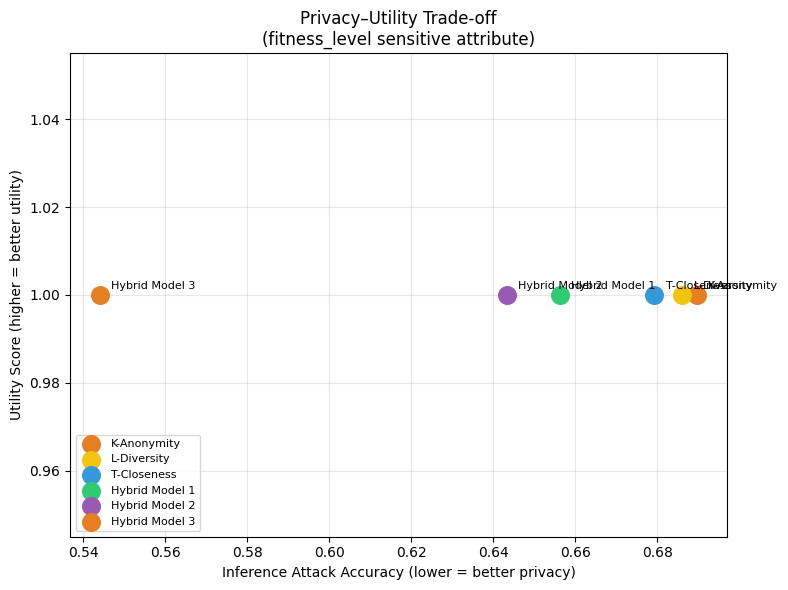

✅ Saved: ../results/10_privacy_utility_scatter.png


In [16]:
# ── Visualisation 2: Privacy vs Utility scatter ──────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for i, (m, a, u) in enumerate(zip(methods, acc, util)):
    ax.scatter(a, u, s=160, color=colours[i % len(colours)], zorder=3, label=m)
    ax.annotate(m, (a, u), textcoords='offset points', xytext=(8, 4), fontsize=8)

ax.set_xlabel('Inference Attack Accuracy (lower = better privacy)')
ax.set_ylabel('Utility Score (higher = better utility)')
ax.set_title('Privacy–Utility Trade-off\n(fitness_level sensitive attribute)', fontsize=12)
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/10_privacy_utility_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/10_privacy_utility_scatter.png')

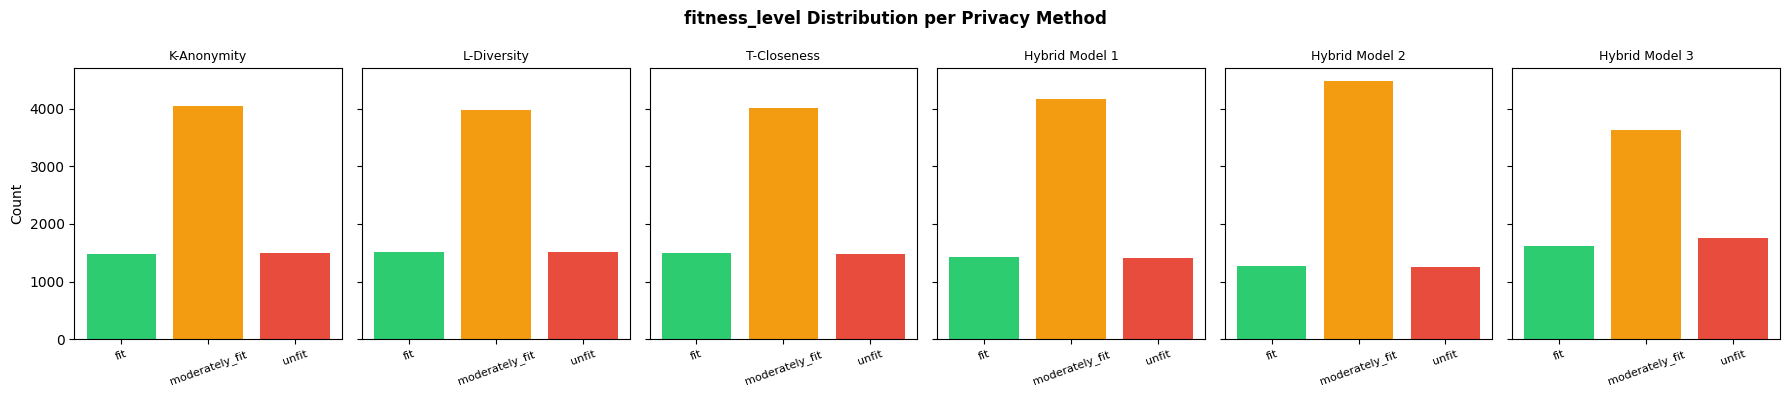

✅ Saved: ../results/10_fitness_level_per_method.png


In [14]:
# ── Visualisation 3: fitness_level distribution per method ───────────
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 4), sharey=True)

for ax, (mname, df_m) in zip(axes, datasets.items()):
    counts = df_m['fitness_level'].value_counts().reindex(fitness_classes)
    ax.bar(fitness_classes, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
    ax.set_title(mname, fontsize=9)
    ax.tick_params(axis='x', rotation=20, labelsize=8)

axes[0].set_ylabel('Count')
plt.suptitle('fitness_level Distribution per Privacy Method', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/10_fitness_level_per_method.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/10_fitness_level_per_method.png')

In [17]:
# ── Print Final Results (paper-ready) ───────────────────────────────
best_privacy_idx = comparison_df['Inference Attack Accuracy'].idxmin()
best_utility_idx = comparison_df['Utility Score'].idxmax()

# Best trade-off: lowest attack accuracy PLUS highest utility (simple sum rank)
comparison_df['privacy_rank'] = comparison_df['Inference Attack Accuracy'].rank()
comparison_df['utility_rank'] = comparison_df['Utility Score'].rank(ascending=False)
comparison_df['tradeoff_score'] = comparison_df['privacy_rank'] + comparison_df['utility_rank']
best_tradeoff_idx = comparison_df['tradeoff_score'].idxmin()

best_privacy  = comparison_df.loc[best_privacy_idx]
best_utility  = comparison_df.loc[best_utility_idx]
best_tradeoff = comparison_df.loc[best_tradeoff_idx]

print()
print('=' * 70)
print('  FINAL RESULTS — FOR PAPER')
print('  Sensitive attribute: fitness_level')
print('  Privacy metric:      Inference Attack Accuracy (lower is better)')
print('  TVD metric:          Mean Total Variation Distance from population')
print('  Utility metric:      Normalised numeric attribute fidelity')
print('=' * 70)
print()
print(f"🔒 BEST PRIVACY:")
print(f"   Method:   {best_privacy['Method']}")
print(f"   Attack accuracy:  {best_privacy['Inference Attack Accuracy']:.4f}")
print(f"   Mean TVD:         {best_privacy['Mean TVD (privacy metric)']:.4f}")
print(f"   Utility:          {best_privacy['Utility Score']:.4f}")
print()
print(f"📊 BEST UTILITY:")
print(f"   Method:   {best_utility['Method']}")
print(f"   Attack accuracy:  {best_utility['Inference Attack Accuracy']:.4f}")
print(f"   Mean TVD:         {best_utility['Mean TVD (privacy metric)']:.4f}")
print(f"   Utility:          {best_utility['Utility Score']:.4f}")
print()
print(f"⚖️  BEST PRIVACY–UTILITY TRADE-OFF:")
print(f"   Method:   {best_tradeoff['Method']}")
print(f"   Attack accuracy:  {best_tradeoff['Inference Attack Accuracy']:.4f}")
print(f"   Mean TVD:         {best_tradeoff['Mean TVD (privacy metric)']:.4f}")
print(f"   Utility:          {best_tradeoff['Utility Score']:.4f}")
print()
print(f"📝 CONCLUSION:")
print(f"   {best_tradeoff['Method']} achieves the lowest inference attack accuracy "
      f"while preserving high data utility, demonstrating the best "
      f"privacy-utility trade-off among all evaluated methods.")
print('=' * 70)


  FINAL RESULTS — FOR PAPER
  Sensitive attribute: fitness_level
  Privacy metric:      Inference Attack Accuracy (lower is better)
  TVD metric:          Mean Total Variation Distance from population
  Utility metric:      Normalised numeric attribute fidelity

🔒 BEST PRIVACY:
   Method:   Hybrid Model 3
   Attack accuracy:  0.5441
   Mean TVD:         0.1617
   Utility:          1.0000

📊 BEST UTILITY:
   Method:   K-Anonymity
   Attack accuracy:  0.6897
   Mean TVD:         0.2812
   Utility:          1.0000

⚖️  BEST PRIVACY–UTILITY TRADE-OFF:
   Method:   Hybrid Model 3
   Attack accuracy:  0.5441
   Mean TVD:         0.1617
   Utility:          1.0000

📝 CONCLUSION:
   Hybrid Model 3 achieves the lowest inference attack accuracy while preserving high data utility, demonstrating the best privacy-utility trade-off among all evaluated methods.


In [18]:
# Save final summary JSON
summary_out = {
    'sensitive_attribute': 'fitness_level',
    'best_privacy_method':  best_privacy['Method'],
    'best_utility_method':  best_utility['Method'],
    'best_tradeoff_method': best_tradeoff['Method'],
    'comparison_table': comparison_df.drop(columns=['privacy_rank', 'utility_rank', 'tradeoff_score']).to_dict(orient='records')
}

with open('../results/10_final_paper_results.json', 'w') as f:
    json.dump(summary_out, f, indent=2)

print('✅ Saved: ../results/10_final_paper_results.json')
print('\nAll outputs written to ../results/')

✅ Saved: ../results/10_final_paper_results.json

All outputs written to ../results/
